<a href="https://colab.research.google.com/github/quirogaez/capstone/blob/main/11_IMAGE_GENERATOR_MODEL_GradCam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



## 1. Descripción General

- **Objetivo:**  
  Copiar desde el directorio de imágenes redimensionadas hacia una estructura de carpetas `classification_dataV4-test/{train,val,test}/{NORMAL,VIRAL,BACTERIAL}`.

- **Clases finales:**  
  - NORMAL  
  - VIRAL (imágenes que en el nombre contienen “virus”)  
  - BACTERIAL (imágenes que en el nombre contienen “bact”)


In [ ]:
import shutil
from pathlib import Path

# Ruta original
SRC = Path("/workspace/data/redimensionadas")
# Ruta destino
DST = Path("/workspace/data/classification_dataV4-test")
splits = ["train", "val", "test"]

for split in splits:
    for cls in ["NORMAL", "VIRAL", "BACTERIAL"]:
        (DST/split/cls).mkdir(parents=True, exist_ok=True)

    # Copiar NORMAL
    for img in (SRC/split/"NORMAL").iterdir():
        shutil.copy(img, DST/split/"NORMAL"/img.name)

    # De PNEUMONIA extraer por nombre
    for img in (SRC/split/"PNEUMONIA").iterdir():
        name = img.stem.lower()
        if "virus" in name:
            target = "VIRAL"
        elif "bact" in name:
            target = "BACTERIAL"
        else:
            continue
        shutil.copy(img, DST/split/target/img.name)


## 2. Fine-tuning y Generación Sintética con GAN

### 2.1 Objetivo
- **Siempre Retomar** un GAN (Generator + Discriminator) ya entrenado hasta cierta época.
- **Añadir** `MORE_EPOCHS` de entrenamiento extra (fine-tuning).
- **Generar** imágenes sintéticas por clase hasta emparejar el tamaño máximo (`max_count`) y lograr un dataset balanceado.

El objetivo es mejorar su capacidad para crear radiografías de tórax sintéticas de tres clases ―**NORMAL**, **VIRAL** y **BACTERIAL**― y, después, usar ese generador para equilibrar el número de ejemplos por categoría dentro del conjunto de entrenamiento.


###  Configuración inicial
- **Resolución** de salida: **224 × 224 px** en escala de grises (`CHANNELS = 1`).  
- **Vector ruido**: `LATENT_DIM = 100`.  
- **Clases**: `["NORMAL", "VIRAL", "BACTERIAL"]`.  
- **Tamaño de lote**: `BATCH_SIZE = 16`.  
- **Épocas extra**: `MORE_EPOCHS = 200`.  
- **Rutas clave**:  
  - `TRAIN_DIR` → carpeta de imágenes reales de entrenamiento.  
  - `CKPT_DIR`  → carpeta para guardar / restaurar checkpoints.

---

###  Arquitectura
- **Generator**  
  - Entrada: vector de ruido + etiqueta de clase (Embedding).  
  - Pila de *Conv2DTranspose* con *BatchNorm* y *LeakyReLU*.  
  - Bloque de **Self-Attention** en resolución 14 × 14.  
  - Salida: imagen 224 × 224 × 1 con activación `tanh`.

- **Discriminator**  
  - Concatena la imagen (real o sintética) con un mapa que codifica la clase.  
  - Varias *Conv2D* con **Spectral Normalization** y *LeakyReLU*.  
  - Capa densa final → logit autenticidad.

- **Pérdidas**: _Hinge loss_ para ambos modelos.  
- **Optimización**: TTUR (Adam 1e-4 para G, 4e-4 para D, `β₁ = 0.5`).

---

###  Flujo de entrenamiento
1. **Preparar dataset**  
   - Leer JPEG → convertir a tensor, redimensionar, normalizar a \[-1, 1\].  
   - Mezclar, agrupar en lotes y pre-cargar con `tf.data`.

2. **Restaurar checkpoint** (si existe)  
   - Detectar la última época entrenada.  
   - Reducir las tasas de aprendizaje al 50 % para comenzar _fine-tuning_.

3. **Bucle de épocas** (`start_epoch` → `end_epoch`)  
   - Por lote:  
     - Añadir 📉 **ruido Gaussiano** muy leve a la imagen real (estabilidad).  
     - Calcular y aplicar gradientes para Generador y Discriminador.  
   - Cada 10 épocas (o la última): guardar nuevo checkpoint numerado.

---

###  Generación sintética y balanceo
- Calcular **conteo real** de imágenes por clase.  
- Determinar cuántas faltan para igualar a la clase mayoritaria (`max_count`).  
- Para cada muestra faltante:  
  1. Muestrear vector de ruido + etiqueta fija.  
  2. Generar imagen con el Generador _congelado_.  
  3. Re-escalar \[-1, 1\] → \[0, 255\] y guardar como JPEG en la carpeta de su clase.

- Resultado final: **todas las clases tienen exactamente `max_count` imágenes**.

---



In [ ]:
import os
import re
import tensorflow as tf
import tensorflow_addons as tfa
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.image import save_img
from pathlib import Path

# ----------------------------------------
# 1) Parámetros y rutas
# ----------------------------------------
IMG_HEIGHT = 224
IMG_WIDTH  = 224
CHANNELS   = 1
LATENT_DIM = 100
CLASSES    = ["NORMAL", "VIRAL", "BACTERIAL"]
BATCH_SIZE = 16


MORE_EPOCHS = 200

TRAIN_DIR = Path("/workspace/data/classification_dataV4-test/train")
CKPT_DIR  = Path("/workspace/checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

# ----------------------------------------
# 2) Definición de Generator y Discriminator
# ----------------------------------------
def build_generator():
    noise = layers.Input((LATENT_DIM,))
    label = layers.Input((1,), dtype='int32')
    emb   = layers.Embedding(len(CLASSES), LATENT_DIM)(label)
    emb   = layers.Flatten()(emb)
    x     = layers.multiply([noise, emb])
    x     = layers.Dense(7*7*512, use_bias=False)(x)
    x     = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)
    x     = layers.Reshape((7,7,512))(x)

    # Upsample 7→14
    x = layers.Conv2DTranspose(256, (5,5), strides=2, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    # Self-Attention sobre 14×14
    h, w, c = 14, 14, 256
    x_ = layers.Reshape((h*w, c))(x)
    attn = layers.MultiHeadAttention(num_heads=4, key_dim=c//4)(x_, x_)
    x   = layers.Reshape((h, w, c))(attn)

    # Upsamples 14→28→56→112→224
    for filt in [128, 64, 32, 16]:
        x = layers.Conv2DTranspose(filt, (5,5), strides=2, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x); x = layers.LeakyReLU(0.2)(x)

    img = layers.Conv2D(CHANNELS, (7,7), activation='tanh', padding='same')(x)
    return Model([noise, label], img, name="generator")

def build_discriminator():
    img   = layers.Input((IMG_HEIGHT, IMG_WIDTH, CHANNELS))
    label = layers.Input((1,), dtype='int32')
    emb   = layers.Embedding(len(CLASSES), IMG_HEIGHT*IMG_WIDTH)(label)
    emb   = layers.Reshape((IMG_HEIGHT, IMG_WIDTH, 1))(emb)
    x     = layers.Concatenate()([img, emb])
    for filt in [16, 32, 64, 128]:
        x = tfa.layers.SpectralNormalization(
                layers.Conv2D(filt, (5,5), strides=2, padding='same')
            )(x)
        x = layers.LeakyReLU(0.2)(x); x = layers.Dropout(0.3)(x)
    x   = layers.Flatten()(x)
    out = tfa.layers.SpectralNormalization(layers.Dense(1))(x)
    return Model([img, label], out, name="discriminator")

# Hinge losses
def d_hinge(real, fake):
    return tf.reduce_mean(tf.nn.relu(1.-real)) + tf.reduce_mean(tf.nn.relu(1.+fake))
def g_hinge(fake):
    return -tf.reduce_mean(fake)

# ----------------------------------------
# 3) Instancia modelos y optimizadores (TTUR)
# ----------------------------------------
generator     = build_generator()
discriminator = build_discriminator()
gen_opt  = tf.keras.optimizers.Adam(1e-4, beta_1=0.5)
disc_opt = tf.keras.optimizers.Adam(4e-4, beta_1=0.5)

# Checkpoint
ckpt = tf.train.Checkpoint(
    gen=generator, gen_opt=gen_opt,
    disc=discriminator, disc_opt=disc_opt
)
manager = tf.train.CheckpointManager(ckpt, CKPT_DIR, max_to_keep=5)

# ----------------------------------------
# 4) Paso de entrenamiento
# ----------------------------------------
@tf.function
def train_step(real_images, real_labels):
    real_noisy = tf.clip_by_value(
        real_images + tf.random.normal(tf.shape(real_images), 0., 0.01),
        -1., 1.
    )
    bs         = tf.shape(real_images)[0]
    noise      = tf.random.normal([bs, LATENT_DIM])
    rnd_labels = tf.random.uniform([bs,1], maxval=len(CLASSES), dtype=tf.int32)
    with tf.GradientTape() as gt, tf.GradientTape() as dt:
        fake = generator([noise, rnd_labels], training=True)
        r_log = discriminator([real_noisy, real_labels], training=True)
        f_log = discriminator([fake, rnd_labels], training=True)
        g_loss = g_hinge(f_log)
        d_loss = d_hinge(r_log, f_log)
    grads_g = gt.gradient(g_loss, generator.trainable_variables)
    grads_d = dt.gradient(d_loss, discriminator.trainable_variables)
    gen_opt.apply_gradients(zip(grads_g, generator.trainable_variables))
    disc_opt.apply_gradients(zip(grads_d, discriminator.trainable_variables))
    return g_loss, d_loss

# ----------------------------------------
# 5) Dataset con tf.data
# ----------------------------------------
def load_ds():
    paths, labels = [], []
    for i,cls in enumerate(CLASSES):
        for p in (TRAIN_DIR/cls).glob("*"):
            paths.append(str(p)); labels.append(i)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    def parse(p, l):
        img = tf.image.decode_jpeg(tf.io.read_file(p), channels=1)
        img = tf.image.resize(img, (IMG_HEIGHT, IMG_WIDTH))
        img = (img - 127.5) / 127.5
        return img, tf.reshape(l, (1,))
    return ds.map(parse, tf.data.AUTOTUNE)\
             .shuffle(1000).batch(BATCH_SIZE)\
             .prefetch(tf.data.AUTOTUNE)

train_ds = load_ds()

# ----------------------------------------
# 6) Restaurar último checkpoint y reajustar LR
# ----------------------------------------
start_epoch = 1
if manager.latest_checkpoint:
    ckpt.restore(manager.latest_checkpoint)
    m = re.search(r"ckpt-(\d+)", manager.latest_checkpoint)
    if m:
        last = int(m.group(1))
        start_epoch = last + 1
    # Reducir learning-rate al retomar
    gen_opt.lr.assign(gen_opt.lr * 0.5)
    disc_opt.lr.assign(disc_opt.lr * 0.5)
    print(f"✅ Restaurado {manager.latest_checkpoint}, reanudar en época {start_epoch}")
    print("🎯 Nuevos LR:", gen_opt.lr.numpy(), disc_opt.lr.numpy())

# ----------------------------------------
# 7) Entrenamiento adicional
# ----------------------------------------
end_epoch = start_epoch + MORE_EPOCHS - 1
for epoch in range(start_epoch, end_epoch + 1):
    for imgs, lbls in train_ds:
        gl, dl = train_step(imgs, lbls)
    if epoch % 10 == 0 or epoch == end_epoch:
        manager.save(checkpoint_number=epoch)
        print(f"Epoch {epoch}/{end_epoch} ▶ gen_loss={gl:.4f}, disc_loss={dl:.4f} ▶ checkpoint saved")

# ----------------------------------------
# 8) Generación final para balanceo
# ----------------------------------------
counts    = {c: len(list((TRAIN_DIR/c).glob("*"))) for c in CLASSES}
max_count = max(counts.values())
for idx, cls in enumerate(CLASSES):
    to_gen = max_count - counts[cls]
    print(f"{cls}: {counts[cls]} reales → generando {to_gen}")
    for i in range(to_gen):
        noise = tf.random.normal([1, LATENT_DIM])
        lab   = tf.constant([[idx]], dtype=tf.int32)
        img   = generator([noise, lab], training=False)
        arr   = (img[0] * 127.5 + 127.5).numpy().astype("uint8")
        arr   = arr.reshape(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
        save_img(str(TRAIN_DIR/cls/f"{cls}_gen_{i+1:04d}.jpeg"), arr, scale=False)

print("✔ Balanceo completado: cada clase tiene", max_count, "imágenes.")


✅ Restaurado /workspace/checkpoints/ckpt-400, fine-tune desde ep 401
🎯 Nuevos LR: 5e-05 0.0002


2025-07-13 21:00:21.054232: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype int32 and shape [5144]
	 [[{{node Placeholder/_1}}]]
2025-07-13 21:00:21.054673: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [5144]
	 [[{{node Placeholder/_0}}]]
2025-07-13 21:00:23.069367: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape indiscriminator/dropout_16/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-07-13 21:00:41.027347: E tensorflow/

Epoch 410: gen_loss=0.6291, disc_loss=0.9571 ▶ checkpoint guardado
Epoch 420: gen_loss=0.9347, disc_loss=0.8151 ▶ checkpoint guardado
Epoch 430: gen_loss=0.0907, disc_loss=0.9923 ▶ checkpoint guardado
Epoch 440: gen_loss=0.4409, disc_loss=0.7478 ▶ checkpoint guardado
Epoch 450: gen_loss=0.3940, disc_loss=0.9876 ▶ checkpoint guardado
Epoch 460: gen_loss=0.7003, disc_loss=0.8189 ▶ checkpoint guardado
Epoch 470: gen_loss=0.3520, disc_loss=0.7675 ▶ checkpoint guardado
Epoch 480: gen_loss=0.7015, disc_loss=1.0630 ▶ checkpoint guardado
Epoch 490: gen_loss=0.4152, disc_loss=0.7980 ▶ checkpoint guardado
Epoch 500: gen_loss=-0.2366, disc_loss=1.8520 ▶ checkpoint guardado
Epoch 510: gen_loss=0.0624, disc_loss=0.9872 ▶ checkpoint guardado
Epoch 520: gen_loss=0.7289, disc_loss=0.6498 ▶ checkpoint guardado
Epoch 530: gen_loss=0.0088, disc_loss=1.4264 ▶ checkpoint guardado
Epoch 540: gen_loss=0.1090, disc_loss=1.2526 ▶ checkpoint guardado
Epoch 550: gen_loss=0.2228, disc_loss=1.3318 ▶ checkpoint gua

## 3. Modelo ImageNet

### Configuración inicial
- **Estructura de carpetas**  
  - `BASE_DIR/train` → entrenamiento  
  - `BASE_DIR/val`   → validación  
  - `BASE_DIR/test`  → prueba
- **Dimensiones**: 224 × 224 px, 3 canales (RGB).  
- **Batch size**: 32.  
- **Optimización**: Adam `1e-4` (fase 1) → `1e-5` (fase 2).  
- **Callbacks**:  
  - *EarlyStopping* (paciencia = 5, restaura mejor checkpoint)  
  - *ReduceLROnPlateau* (factor 0.5, paciencia = 3)  
  - *ModelCheckpoint* (`best_vgg16.h5`, guarda cuando sube `val_accuracy`)

---

###  Balance de clases
- Se contabilizan imágenes por clase en `TRAIN_DIR`.  
- Se calcula `class_weight` = *(tamaño de la clase mayor / tamaño de cada clase)* para mitigar el desbalance durante el entrenamiento.

---

###  Generación de datos
- **Entrenamiento**:  
  - Reescalado 1/255  
  - Aumentos: rotación ±15°, traslación 10 %, zoom 10 %, _flip_ horizontal, brillo (0.8–1.2), _shear_ 5 %, relleno *nearest*.  
- **Validación & Test**: solo reescalado 1/255.  
- Los *ImageDataGenerator* producen lotes etiquetados en modo _categorical_.

---

###  Modelo
- **Base**: `VGG16(weights="imagenet", include_top=False)` congelada inicialmente.  
- **Cabeza**:  
  1. `Flatten`  
  2. `Dense(256, relu)`  
  3. `Dropout(0.5)`  
  4. `Dense(n_clases, softmax)`  

---

###  Entrenamiento
1. **Fase 1 – Solo la cabeza**  
   - Épocas: 15  
   - `base.trainable = False`  
   - Ponderación de clases aplicada.  
2. **Fase 2 – Fine-tuning**  
   - Se descongelan las **4 últimas capas convolucionales** de VGG-16.  
   - LR reducido a `1e-5`.  
   - Épocas: 10 adicionales.  
   - Misma estrategia de *callbacks* y *class_weight*.

### Conclusiones
- El modelo alcanza **87 % de precisión** en el conjunto de prueba, mostrando alto _recall_ para **BACTERIAL** y **VIRAL**, y excelente precisión para **NORMAL**.  
- En validación, la clase **VIRAL** es minoritaria (sin ejemplos), lo que explica la falta de métricas.
- El archivo `vgg16_finetuned_entrega.h5` contiene los pesos óptimos listos para inferencia o despliegue.

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

# 1) Rutas
BASE_DIR = "/workspace/data/classification_dataV4-4-test"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

# 2) Contar ejemplos por clase para class_weight
classes = sorted(os.listdir(TRAIN_DIR))
counts = {cls: len(os.listdir(os.path.join(TRAIN_DIR, cls))) for cls in classes}
max_count = max(counts.values())
class_weight = {i: max_count / counts[cls] for i, cls in enumerate(classes)}

# 3) Generadores de imágenes
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    shear_range=0.05,
    fill_mode="nearest"
)
valtest_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=True,
    seed=42
)
val_gen = valtest_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)
test_gen = valtest_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

# 4) Modelo con VGG16
base = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))
base.trainable = False   # congelar toda la base

model = Sequential([
    base,
    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(len(classes), activation="softmax")
])

model.compile(
    optimizer=Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

# 5) Callbacks
cbs = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
    ModelCheckpoint("best_vgg16.h5", monitor="val_accuracy", save_best_only=True)
]

# 6) Entrenamiento fase 1 (solo cabeza)
history1 = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=cbs
)

# 7) Fine‑tuning: descongelar últimas 4 capas convolucionales
base.trainable = True
for layer in base.layers[:-4]:
    layer.trainable = False

model.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    class_weight=class_weight,
    callbacks=cbs
)

# 8) Evaluación final en Test
loss, acc = model.evaluate(test_gen, verbose=1)
print(f"\nTest accuracy: {acc*100:.2f}%")

# 9) Classification report y matriz de confusión
#   Necesitamos etiquetas y predicciones en crudo
test_gen.reset()
y_true = test_gen.classes
y_prob = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))


2025-07-15 23:50:03.385197: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 7590 images belonging to 3 classes.
Found 16 images belonging to 3 classes.
Found 624 images belonging to 3 classes.


2025-07-15 23:50:05.426323: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.444154: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.444446: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.446313: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:982] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-07-15 23:50:05.446576: I tensorflow/compile

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 256)               6422784   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 3)                 771       
                                                                 
Total params: 21,138,243
Trainable params: 6,423,555
Non-trainable params: 14,714,688
_________________________________________________________________
Epoch 1/15


2025-07-15 23:50:07.123674: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-07-15 23:50:07.751837: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8600
2025-07-15 23:50:08.753685: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-07-15 23:50:08.798896: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x7a8d2804ef10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-07-15 23:50:08.798940: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2025-07-15 23:50:08.80

...

238/238 [==============================] - 38s 155ms/step - loss: 0.4053 - accuracy: 0.8281 - val_loss: 0.7949 - val_accuracy: 0.6875 - lr: 1.0000e-05
Epoch 2/10
238/238 [==============================] - 37s 157ms/step - loss: 0.3641 - accuracy: 0.8440 - val_loss: 0.6778 - val_accuracy: 0.7500 - lr: 1.0000e-05
Epoch 3/10
238/238 [==============================] - 38s 157ms/step - loss: 0.3497 - accuracy: 0.8531 - val_loss: 0.7895 - val_accuracy: 0.5625 - lr: 1.0000e-05
Epoch 4/10
238/238 [==============================] - 38s 158ms/step - loss: 0.3353 - accuracy: 0.8568 - val_loss: 0.7625 - val_accuracy: 0.7500 - lr: 1.0000e-05
Epoch 5/10
238/238 [==============================] - 37s 157ms/step - loss: 0.3224 - accuracy: 0.8582 - val_loss: 0.8939 - val_accuracy: 0.6250 - lr: 1.0000e-05
Epoch 6/10
238/238 [==============================] - 38s 158ms/step - loss: 0.3153 - accuracy: 0.8639 - val_loss: 0.5378 - val_accuracy: 0.7500 - lr: 5.0000e-06
Epoch 7/10
 2/20 [==>..................

2025-07-15 23:58:58.611243: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


20/20 [==============================] - 1s 70ms/step - loss: 0.4814 - accuracy: 0.8718

Test accuracy: 87.18%


2025-07-15 23:59:00.083796: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]



Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       0.87      0.97      0.92       242
      NORMAL       0.95      0.79      0.87       234
       VIRAL       0.78      0.84      0.81       148

    accuracy                           0.87       624
   macro avg       0.87      0.87      0.86       624
weighted avg       0.88      0.87      0.87       624

Confusion Matrix:
[[234   8   0]
 [ 12 186  36]
 [ 22   2 124]]


In [ ]:
# 10) Guardar el modelo nuevamente para exportación
model.save("vgg16_finetuned_entrega.h5")
print("Modelo guardado en vgg16_finetuned.h5")

# — Guardar en el formato TensorFlow SavedModel —
model.save("vgg16_savedmodel_entrega", save_format="tf")
print("Modelo guardado en la carpeta 'vgg16_savedmodel'")


Modelo guardado en vgg16_finetuned.h5


2025-07-15 23:59:22.332624: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,256]
	 [[{{node inputs}}]]
2025-07-15 23:59:22.602288: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'inputs' with dtype float and shape [?,256]
	 [[{{node inputs}}]]


INFO:tensorflow:Assets written to: vgg16_savedmodel_entrega/assets


INFO:tensorflow:Assets written to: vgg16_savedmodel_entrega/assets


Modelo guardado en la carpeta 'vgg16_savedmodel'


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Si aún no lo tienes, extrae los nombres de clase desde tu generador de train:
classes = list(train_gen.class_indices.keys())

# 1) Evaluar accuracy sobre validación
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\nValidation accuracy: {val_acc*100:.2f}%")

# 2) Reporte de clasificación y matriz de confusión
val_gen.reset()
y_val_true = val_gen.classes
y_val_prob = model.predict(val_gen, verbose=0)
y_val_pred = np.argmax(y_val_prob, axis=1)

print("\nValidation Classification Report:")
print(classification_report(
    y_val_true,
    y_val_pred,
    target_names=classes
))

print("Validation Confusion Matrix:")
print(confusion_matrix(y_val_true, y_val_pred))


2025-07-15 23:59:13.261010: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]


1/1 [==============================] - 0s 308ms/step - loss: 0.6778 - accuracy: 0.7500

Validation accuracy: 75.00%

Validation Classification Report:
              precision    recall  f1-score   support

   BACTERIAL       1.00      0.50      0.67         8
      NORMAL       0.89      1.00      0.94         8
       VIRAL       0.00      0.00      0.00         0

    accuracy                           0.75        16
   macro avg       0.63      0.50      0.54        16
weighted avg       0.94      0.75      0.80        16

Validation Confusion Matrix:
[[4 1 3]
 [0 8 0]
 [0 0 0]]


2025-07-15 23:59:13.593529: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classificati

Example 1: Processing some images with visualization...
Starting batch processing...
Images will be saved to: /content/drive/MyDrive/Capstone/GradCam

Found 234 images in NORMAL category
Processing NORMAL [1/2]: IM-0033-0001.jpeg
Saved: /content/drive/MyDrive/Capstone/GradCam/test_normal/IM-0033-0001_gradcam.png


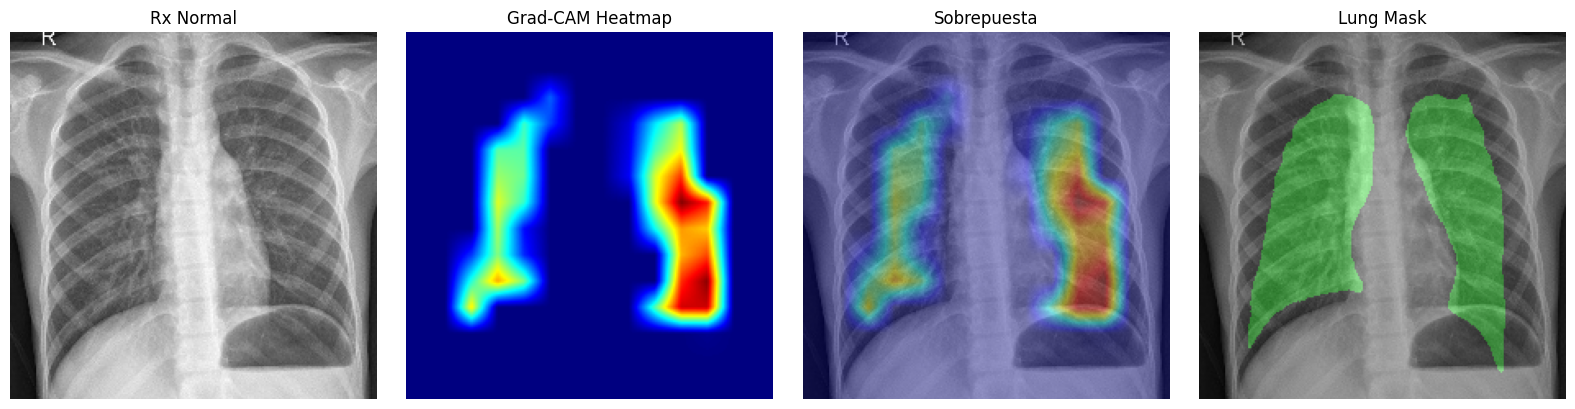


Analysis for IM-0033-0001.jpeg:
True Class: Rx Normal
Predicted Class: NORMAL (Confidence: 0.559)
All Predictions: {'BACTERIAL': np.float32(0.19240399), 'NORMAL': np.float32(0.5592465), 'VIRAL': np.float32(0.24834958)}
Processing NORMAL [2/2]: IM-0083-0001.jpeg
Saved: /content/drive/MyDrive/Capstone/GradCam/test_normal/IM-0083-0001_gradcam.png


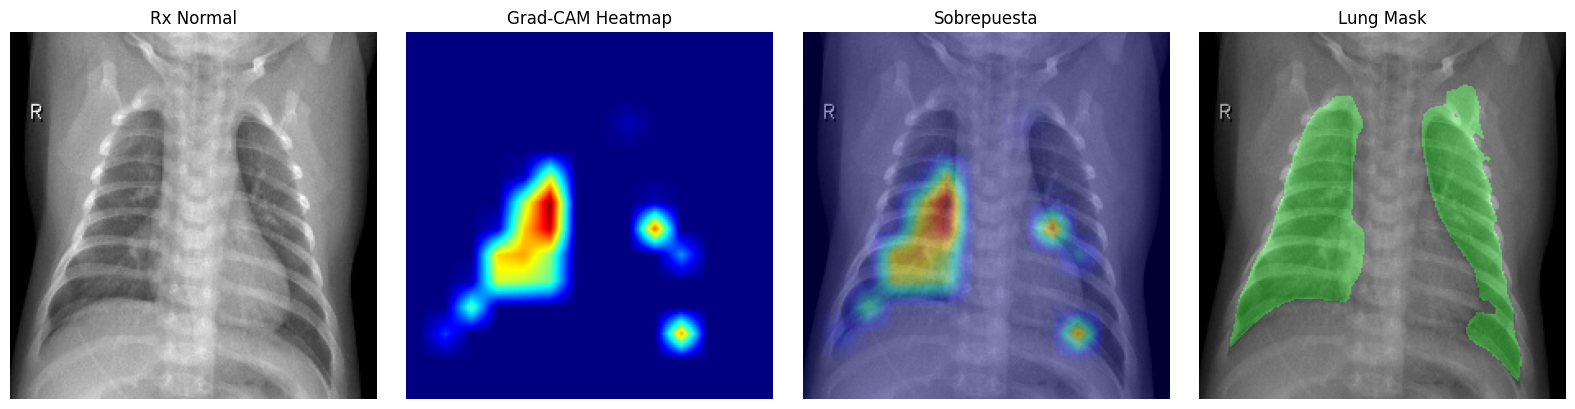


Analysis for IM-0083-0001.jpeg:
True Class: Rx Normal
Predicted Class: NORMAL (Confidence: 0.841)
All Predictions: {'BACTERIAL': np.float32(0.06737752), 'NORMAL': np.float32(0.8408339), 'VIRAL': np.float32(0.09178857)}

Found 242 images in BACTERIAL category
Processing BACTERIAL [1/2]: person109_bacteria_512.jpeg
Saved: /content/drive/MyDrive/Capstone/GradCam/test_bacterial/person109_bacteria_512_gradcam.png


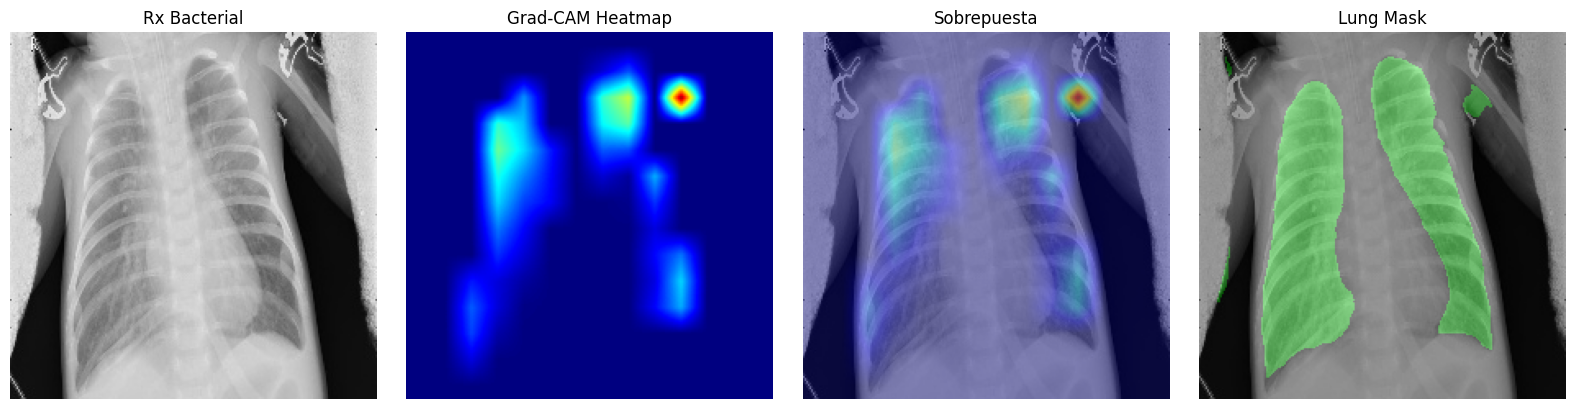


Analysis for person109_bacteria_512.jpeg:
True Class: Rx Bacterial
Predicted Class: BACTERIAL (Confidence: 0.831)
All Predictions: {'BACTERIAL': np.float32(0.83126116), 'NORMAL': np.float32(0.007513003), 'VIRAL': np.float32(0.16122584)}
Lung Activation - Mean: 0.224, Max: 1.000, Std: 0.190
Pattern Analysis: Bacterial pneumonia typically shows localized, intense activation patterns
Processing BACTERIAL [2/2]: person121_bacteria_579.jpeg
Saved: /content/drive/MyDrive/Capstone/GradCam/test_bacterial/person121_bacteria_579_gradcam.png


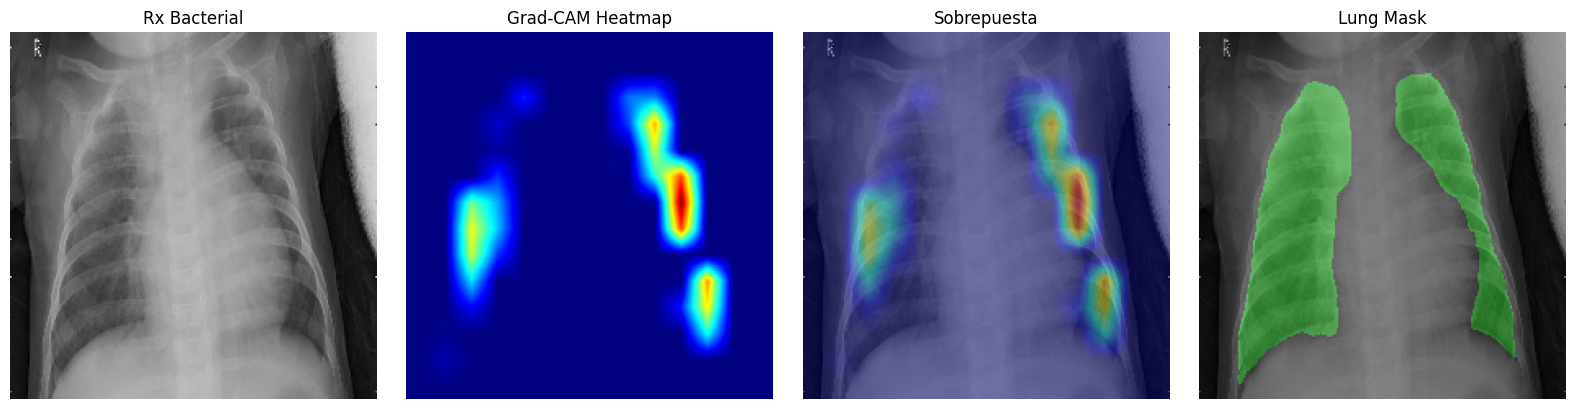


Analysis for person121_bacteria_579.jpeg:
True Class: Rx Bacterial
Predicted Class: BACTERIAL (Confidence: 0.834)
All Predictions: {'BACTERIAL': np.float32(0.8340352), 'NORMAL': np.float32(0.0032836876), 'VIRAL': np.float32(0.16268103)}
Lung Activation - Mean: 0.244, Max: 1.000, Std: 0.285
Pattern Analysis: Bacterial pneumonia typically shows localized, intense activation patterns

Found 148 images in VIRAL category
Processing VIRAL [1/2]: person1_virus_11.jpeg
Saved: /content/drive/MyDrive/Capstone/GradCam/test_bacterial/person1_virus_11_gradcam.png


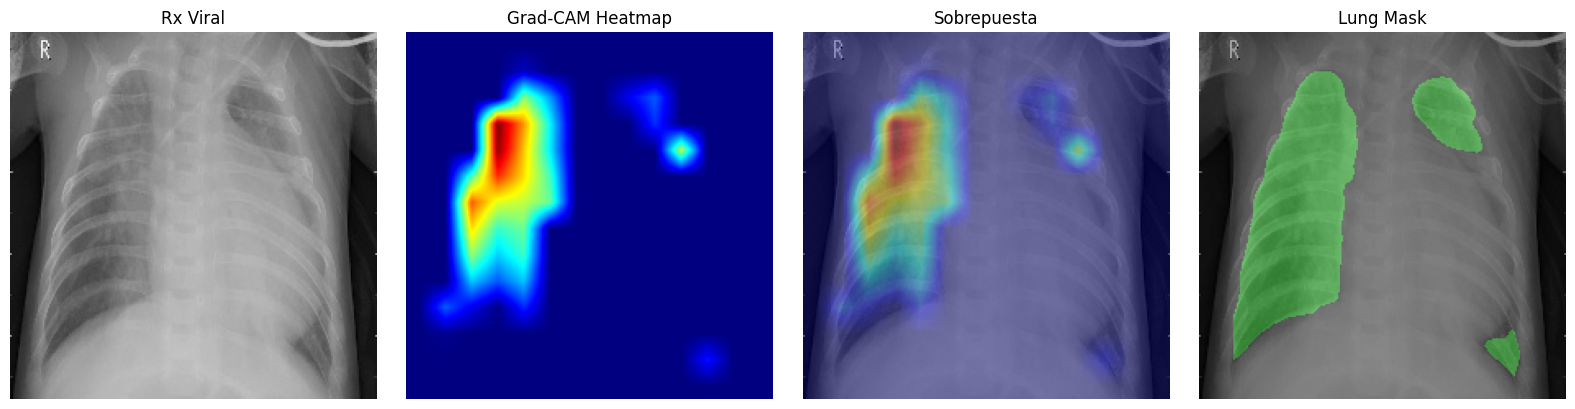


Analysis for person1_virus_11.jpeg:
True Class: Rx Viral
Predicted Class: BACTERIAL (Confidence: 0.902)
All Predictions: {'BACTERIAL': np.float32(0.9017869), 'NORMAL': np.float32(0.0006254331), 'VIRAL': np.float32(0.097587556)}
Lung Activation - Mean: 0.434, Max: 1.000, Std: 0.257
Pattern Analysis: Bacterial pneumonia typically shows localized, intense activation patterns
Processing VIRAL [2/2]: person1627_virus_2819.jpeg
Saved: /content/drive/MyDrive/Capstone/GradCam/test_bacterial/person1627_virus_2819_gradcam.png


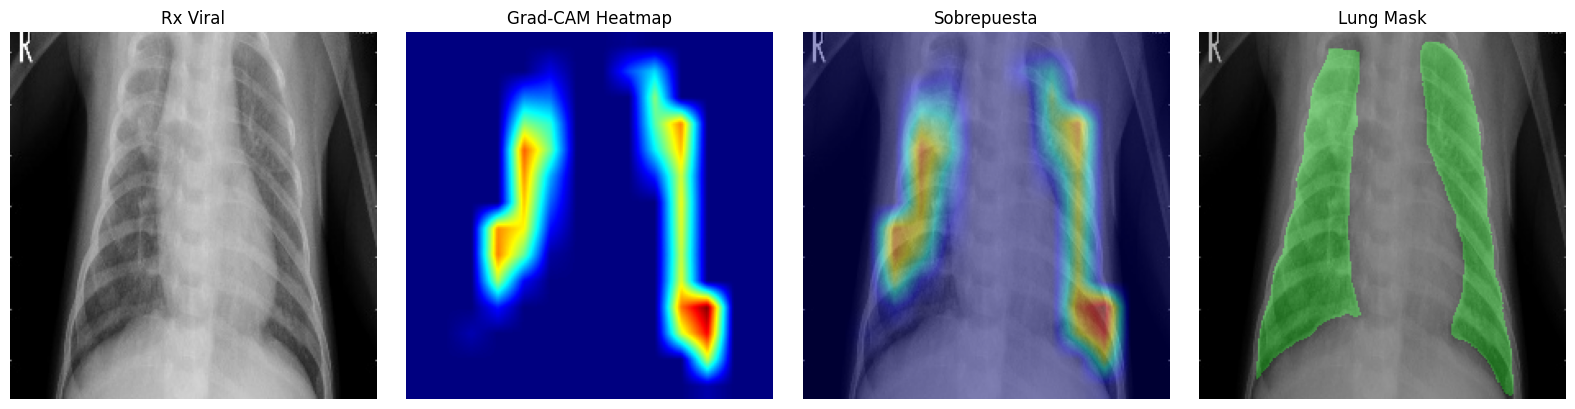


Analysis for person1627_virus_2819.jpeg:
True Class: Rx Viral
Predicted Class: BACTERIAL (Confidence: 0.556)
All Predictions: {'BACTERIAL': np.float32(0.55575675), 'NORMAL': np.float32(0.0046430477), 'VIRAL': np.float32(0.43960026)}
Lung Activation - Mean: 0.424, Max: 1.000, Std: 0.279
Pattern Analysis: Bacterial pneumonia typically shows localized, intense activation patterns

Batch processing completed!
Total images processed: 6
Images saved in:
  - Normal: /content/drive/MyDrive/Capstone/GradCam/test_normal
  - Bacterial: /content/drive/MyDrive/Capstone/GradCam/test_bacterial
  - Viral: /content/drive/MyDrive/Capstone/GradCam/test_viral

Example 2: To process ALL images, run:
all_results = process_all_images(save_images=True, show_plots=False)
Processing ALL images in the dataset...
Starting batch processing...
Images will be saved to: /content/drive/MyDrive/Capstone/GradCam

Found 234 images in NORMAL category
Processing NORMAL [1/234]: IM-0033-0001.jpeg
Saved: /content/drive/MyDr

In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
import glob

# Configuración
BASE_DIR = "/content/drive/MyDrive/Capstone/data/classification_dataV4-4-test/test"
MASK_DIR = "/content/drive/MyDrive/Capstone/data/chest_xray_masks_V2/test"
OUTPUT_DIR = "/content/drive/MyDrive/Capstone/GradCam"

# Crea los directorios de salida
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "test_normal"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "test_bacterial"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "test_viral"), exist_ok=True)

# Mapeo de Clases para la visualización
CLASS_NAMES = {0: 'BACTERIAL', 1: 'NORMAL', 2: 'VIRAL'}  # Adjust based on your model's class order
CLASS_COLORS = {
    'BACTERIAL': [255, 0, 0],    # Red for bacterial
    'NORMAL': [0, 255, 0],       # Green for normal
    'VIRAL': [0, 0, 255]         # Blue for viral
}

# Mapping from directory structure to display names
TRUE_CLASS_DISPLAY = {
    'NORMAL': 'Rx Normal',
    'PNEUMONIA': 'Rx Pneumonia',  # This will be further refined based on prediction
    'BACTERIAL': 'Rx Bacterial',
    'VIRAL': 'Rx Viral'
}

# 1) Reconstruct VGG16 model (same as original)
base = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False

model = Sequential([
    base,
    Flatten(name="flatten"),
    Dense(256, activation="relu", name="fc1"),
    Dropout(0.5, name="dropout"),
    Dense(3, activation="softmax", name="predictions")  # Adjust to your number of classes
])
model.compile(optimizer=Adam(1e-5), loss="categorical_crossentropy", metrics=["accuracy"])
model.load_weights("/content/drive/MyDrive/Capstone/saved_models/VGG16/best_vgg16.h5")

# 2) Model architecture setup (same as original)
last_conv_name = "block5_conv3"
pool_name = "block5_pool"

last_conv_layer = base.get_layer(last_conv_name)
last_conv_model = tf.keras.Model(inputs=base.input, outputs=last_conv_layer.output)

conv_shape = last_conv_layer.output.shape[1:]
conv_input = Input(shape=conv_shape)

x = base.get_layer(pool_name)(conv_input)
x = Flatten()(x)
x = model.get_layer("fc1")(x)
x = model.get_layer("dropout")(x, training=False)
output = model.get_layer("predictions")(x)

classifier_model = tf.keras.Model(inputs=conv_input, outputs=output)


# 3) Enhanced utility functions
def get_true_class_from_path(img_path):
    """Determine the true class from the image path."""
    # Extract the parent directory name
    parent_dir = os.path.basename(os.path.dirname(img_path))

    # Map VGG16 directory structure to true class
    if parent_dir == 'NORMAL':
        return 'NORMAL', 'Rx Normal'
    elif parent_dir == 'BACTERIAL':
        return 'BACTERIAL', 'Rx Bacterial'
    elif parent_dir == 'VIRAL':
        return 'VIRAL', 'Rx Viral'
    else:
        return 'UNKNOWN', 'Rx Unknown'


def get_refined_class_display(true_class_dir, predictions):
    """Get refined class display name based on true class."""
    # For VGG16 structure, we already have the specific class
    if true_class_dir == 'NORMAL':
        return 'Rx Normal'
    elif true_class_dir == 'BACTERIAL':
        return 'Rx Bacterial'
    elif true_class_dir == 'VIRAL':
        return 'Rx Viral'
    else:
        return 'Rx Unknown'


def find_mask_file(img_filename, mask_dir, true_class_dir):
    """Find corresponding mask file for an image based on the mask directory structure."""
    base_name = os.path.splitext(img_filename)[0]

    # Determine which mask folder to look in based on true class
    if true_class_dir == 'NORMAL':
        mask_folder = os.path.join(mask_dir, 'NORMAL')
    elif true_class_dir in ['BACTERIAL', 'VIRAL']:
        mask_folder = os.path.join(mask_dir, 'PNEUMONIA')
    else:
        return None

    if not os.path.exists(mask_folder):
        print(f"Warning: Mask folder {mask_folder} does not exist")
        return None

    # Try different possible mask file patterns
    possible_patterns = [
        f"{base_name}_mask.png",
        f"{base_name}_mask.jpg",
        f"{base_name}.png",
        f"{base_name}.jpg"
    ]

    for pattern in possible_patterns:
        mask_path = os.path.join(mask_folder, pattern)
        if os.path.exists(mask_path):
            return mask_path

    # If no exact match, try searching by base name
    search_patterns = [
        os.path.join(mask_folder, f"*{base_name}*"),
        os.path.join(mask_folder, f"{base_name}*")
    ]

    for pattern in search_patterns:
        matches = glob.glob(pattern)
        if matches:
            return matches[0]

    print(f"Warning: No mask found for {img_filename} in {mask_folder}")
    return None


def load_and_preprocess_mask(mask_path, target_size=(224, 224)):
    """Load and preprocess lung mask."""
    if mask_path is None or not os.path.exists(mask_path):
        return None

    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None

    # Resize mask to match model input size
    mask = cv2.resize(mask, target_size)

    # Normalize mask to 0-1 range
    mask = mask.astype(np.float32) / 255.0

    # Ensure binary mask (threshold at 0.5)
    mask = (mask > 0.5).astype(np.float32)

    return mask


def filter_non_generated_images(directory):
    """Filter out images containing 'gen' in their filename."""
    all_images = []
    for category in ['NORMAL', 'BACTERIAL', 'VIRAL']:  # Updated for VGG16 structure
        category_path = os.path.join(directory, category)
        if os.path.exists(category_path):
            for img_file in os.listdir(category_path):
                if img_file.lower().endswith(('.png', '.jpg', '.jpeg')) and 'gen' not in img_file.lower():
                    all_images.append(os.path.join(category_path, img_file))
        else:
            print(f"Warning: Category path {category_path} does not exist")
    return all_images


# 4) Enhanced Grad-CAM function with mask integration
def make_gradcam_heatmap_with_mask(img_array, last_conv_model, classifier_model,
                                   lung_mask=None, pred_index=None):
    """Generate Grad-CAM heatmap focused on lung regions."""
    # Generate standard Grad-CAM
    conv_outputs = last_conv_model(img_array)
    with tf.GradientTape() as tape:
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)).numpy()

    conv_outputs = conv_outputs[0].numpy()
    for i in range(pooled_grads.shape[-1]):
        conv_outputs[:, :, i] *= pooled_grads[i]

    heatmap = np.mean(conv_outputs, axis=-1)
    heatmap = np.maximum(heatmap, 0)

    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    # Apply lung mask if available
    if lung_mask is not None:
        # Resize mask to match heatmap size
        mask_resized = cv2.resize(lung_mask, (heatmap.shape[1], heatmap.shape[0]))
        # Apply mask to focus only on lung regions
        heatmap = heatmap * mask_resized

        # Renormalize after masking
        if heatmap.max() > 0:
            heatmap /= heatmap.max()

    return heatmap, preds[0]


# 5) Enhanced visualization function
def create_enhanced_visualization(img_path, heatmap, predictions, lung_mask=None, alpha=0.4):
    """Create enhanced visualization with lung mask overlay."""
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    # Resize heatmap to match image size
    hm_resized = cv2.resize(np.uint8(255 * heatmap), (w, h))
    hm_color = cv2.applyColorMap(hm_resized, cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)

    # Create overlay
    overlay = hm_color * alpha + img * (1 - alpha)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    # Create mask overlay if available
    mask_overlay = None
    if lung_mask is not None:
        mask_resized = cv2.resize(lung_mask, (w, h))
        mask_color = np.zeros((h, w, 3), dtype=np.uint8)
        mask_color[:, :, 1] = (mask_resized * 255).astype(np.uint8)  # Green mask
        mask_overlay = img * 0.7 + mask_color * 0.3
        mask_overlay = np.clip(mask_overlay, 0, 255).astype(np.uint8)

    return img, hm_color, overlay, mask_overlay


def save_gradcam_visualization(img_path, orig, cmap, overlay, mask_overlay, class_display_name, predictions):
    """Save the Grad-CAM visualization as a combined image."""
    # Determine output folder based on prediction
    pred_class_idx = np.argmax(predictions)
    pred_class = CLASS_NAMES[pred_class_idx]

    if pred_class == 'NORMAL':
        output_folder = "test_normal"
    elif pred_class == 'BACTERIAL':
        output_folder = "test_bacterial"
    elif pred_class == 'VIRAL':
        output_folder = "test_viral"
    else:
        output_folder = "test_normal"  # Fallback

    # Create output path
    img_filename = os.path.splitext(os.path.basename(img_path))[0]
    output_path = os.path.join(OUTPUT_DIR, output_folder, f"{img_filename}_gradcam.png")

    # Create the combined visualization
    fig_cols = 4 if mask_overlay is not None else 3
    fig = plt.figure(figsize=(16, 4))

    images = [orig, cmap, overlay]
    titles = [class_display_name, "Grad-CAM Heatmap", "Sobrepuesta"]

    if mask_overlay is not None:
        images.append(mask_overlay)
        titles.append("Lung Mask")

    for i, (im, title) in enumerate(zip(images, titles)):
        plt.subplot(1, fig_cols, i+1)
        plt.title(title, fontsize=12, fontweight='bold')
        plt.axis("off")
        plt.imshow(im)

    plt.tight_layout()

    # Save the figure
    plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.close()  # Close to free memory

    print(f"Saved: {output_path}")
    return output_path


# 6) Analysis function for different pneumonia types
def analyze_pneumonia_patterns(img_path, predictions, heatmap, lung_mask=None):
    """Analyze pneumonia patterns based on predictions and heatmap."""
    pred_class = np.argmax(predictions)
    confidence = np.max(predictions)
    class_name = CLASS_NAMES[pred_class]

    analysis = {
        'predicted_class': class_name,
        'confidence': confidence,
        'all_predictions': {CLASS_NAMES[i]: predictions[i] for i in range(len(predictions))}
    }

    if lung_mask is not None and class_name in ['BACTERIAL', 'VIRAL']:
        # Analyze heatmap distribution in lung regions
        mask_resized = cv2.resize(lung_mask, (heatmap.shape[1], heatmap.shape[0]))
        lung_heatmap = heatmap * mask_resized

        # Calculate statistics
        lung_activation = lung_heatmap[mask_resized > 0.5]
        if len(lung_activation) > 0:
            analysis['lung_activation_stats'] = {
                'mean': np.mean(lung_activation),
                'max': np.max(lung_activation),
                'std': np.std(lung_activation)
            }

            # Analyze distribution patterns
            if class_name == 'BACTERIAL':
                analysis['pattern_analysis'] = "Bacterial pneumonia typically shows localized, intense activation patterns"
            elif class_name == 'VIRAL':
                analysis['pattern_analysis'] = "Viral pneumonia typically shows more diffuse, bilateral patterns"

    return analysis


# 7) Main processing function
def process_image_with_enhanced_gradcam(img_path, show_plots=True, save_images=False):
    """Process single image with enhanced Grad-CAM analysis."""
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)

    # Generate predictions and heatmap
    predictions = model.predict(x, verbose=0)
    pred_index = np.argmax(predictions[0])

    # Get true class information
    true_class_dir, _ = get_true_class_from_path(img_path)
    class_display_name = get_refined_class_display(true_class_dir, predictions[0])

    # Find and load corresponding mask (now with true_class_dir parameter)
    img_filename = os.path.basename(img_path)
    mask_path = find_mask_file(img_filename, MASK_DIR, true_class_dir)
    lung_mask = load_and_preprocess_mask(mask_path)

    # Skip image if no mask is found
    if lung_mask is None:
        print(f"Skipping {img_filename}: No corresponding mask found")
        return None

    # Generate heatmap with mask integration
    heatmap, pred_probs = make_gradcam_heatmap_with_mask(
        x, last_conv_model, classifier_model, lung_mask, pred_index
    )

    # Create visualizations
    orig, cmap, overlay, mask_overlay = create_enhanced_visualization(
        img_path, heatmap, predictions[0], lung_mask
    )

    # Save images if requested
    saved_path = None
    if save_images:
        saved_path = save_gradcam_visualization(
            img_path, orig, cmap, overlay, mask_overlay,
            class_display_name, predictions[0]
        )

    # Analyze patterns
    analysis = analyze_pneumonia_patterns(img_path, predictions[0], heatmap, lung_mask)

    if show_plots:
        # Create comprehensive visualization
        fig_cols = 4 if lung_mask is not None else 3
        plt.figure(figsize=(16, 4))

        images = [orig, cmap, overlay]
        titles = [class_display_name, "Grad-CAM Heatmap", "Sobrepuesta"]  # Use class display name instead of "Original"

        if lung_mask is not None:
            images.append(mask_overlay)
            titles.append("Lung Mask")

        for i, (im, title) in enumerate(zip(images, titles)):
            plt.subplot(1, fig_cols, i+1)
            plt.title(title)
            plt.axis("off")
            plt.imshow(im)

        plt.tight_layout()
        plt.show()

        # Print analysis
        print(f"\nAnalysis for {os.path.basename(img_path)}:")
        print(f"True Class: {class_display_name}")
        print(f"Predicted Class: {analysis['predicted_class']} (Confidence: {analysis['confidence']:.3f})")
        print(f"All Predictions: {analysis['all_predictions']}")

        if 'lung_activation_stats' in analysis:
            stats = analysis['lung_activation_stats']
            print(f"Lung Activation - Mean: {stats['mean']:.3f}, Max: {stats['max']:.3f}, Std: {stats['std']:.3f}")

        if 'pattern_analysis' in analysis:
            print(f"Pattern Analysis: {analysis['pattern_analysis']}")

    return {
        'image_path': img_path,
        'predictions': predictions[0],
        'heatmap': heatmap,
        'lung_mask': lung_mask,
        'analysis': analysis,
        'true_class_display': class_display_name,
        'saved_path': saved_path
    }


# 8) Batch processing function
def process_multiple_images(num_images=5, categories=['NORMAL', 'BACTERIAL', 'VIRAL'], save_images=False, show_plots=True):
    """Process multiple images for comprehensive analysis."""
    results = []
    total_processed = 0

    print(f"Starting batch processing...")
    if save_images:
        print(f"Images will be saved to: {OUTPUT_DIR}")

    for category in categories:
        category_path = os.path.join(BASE_DIR, category)
        if not os.path.exists(category_path):
            print(f"Warning: Category path {category_path} does not exist")
            continue

        # Get non-generated images
        images = [f for f in os.listdir(category_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg')) and 'gen' not in f.lower()]

        print(f"\nFound {len(images)} images in {category} category")

        # Process subset or all images
        images_to_process = images[:num_images] if num_images > 0 else images

        for i, img_file in enumerate(images_to_process):
            img_path = os.path.join(category_path, img_file)
            print(f"Processing {category} [{i+1}/{len(images_to_process)}]: {img_file}")

            try:
                result = process_image_with_enhanced_gradcam(
                    img_path, show_plots=show_plots, save_images=save_images
                )

                # Skip if no mask was found (result will be None)
                if result is None:
                    print(f"Skipped {img_file}: No mask found")
                    continue

                results.append(result)
                total_processed += 1

                # Progress update
                if save_images and total_processed % 10 == 0:
                    print(f"Progress: {total_processed} images processed")

            except Exception as e:
                print(f"Error processing {img_file}: {str(e)}")
                continue

    print(f"\nBatch processing completed!")
    print(f"Total images processed: {total_processed}")

    if save_images:
        print(f"Images saved in:")
        print(f"  - Normal: {os.path.join(OUTPUT_DIR, 'test_normal')}")
        print(f"  - Bacterial: {os.path.join(OUTPUT_DIR, 'test_bacterial')}")
        print(f"  - Viral: {os.path.join(OUTPUT_DIR, 'test_viral')}")

    return results


def process_all_images(save_images=True, show_plots=False):
    """Process ALL images in the dataset and save them."""
    print("Processing ALL images in the dataset...")
    return process_multiple_images(
        num_images=0,  # 0 means process all images
        categories=['NORMAL', 'BACTERIAL', 'VIRAL'],
        save_images=save_images,
        show_plots=show_plots
    )


# 9) Example usage
if __name__ == "__main__":
    # Option 1: Process a few images with visualization
    print("Example 1: Processing some images with visualization...")
    example_results = process_multiple_images(num_images=2, save_images=True, show_plots=True)

    print("\n" + "="*50)

    # Option 2: Process ALL images and save them (without showing plots)
    print("Example 2: To process ALL images, run:")
    print("all_results = process_all_images(save_images=True, show_plots=False)")

    # Uncomment the following line to process the entire dataset:
all_results = process_all_images(save_images=True, show_plots=False)

In [1]:
!git clone https://github.com/quirogaez/capstone.git


Cloning into 'capstone'...
remote: Enumerating objects: 331, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 331 (delta 96), reused 49 (delta 35), pack-reused 188 (from 2)
Receiving objects: 100% (331/331), 238.17 MiB | 20.61 MiB/s, done.
Resolving deltas: 100% (168/168), done.


In [2]:
%cd capstone/notebooks/

/content/capstone/notebooks


In [3]:
!git config --global user.name "TheWhite73"
!git config --global user.email "amayazabaladaniel@gmail.com.com"


In [ ]:
!cp /content/NombreNotebook.ipynb /content/TuRepositorio/
